# Data Cleaning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/data/dataframe_chat.csv')
df.head(6)

,timestamp,person,message
0,7/10/22 20:14:00,Cena,‎Los mensajes y las llamadas están cifrados de...
1,7/10/22 20:14:00,Cena,‎Creaste este grupo.
2,7/10/22 20:14:08,Paula Echamendi,Me estoy agobiando con los grupos
3,7/10/22 20:14:12,Paula Echamendi,Asiq hablamos por aqui
4,7/10/22 20:14:12,Carmensita,Coño
5,7/10/22 20:14:14,Carmensita,Gracias


In [ ]:
df.shape

(67344, 3)

In [ ]:
df.dropna(subset=['message', 'person'], inplace=True)
df.shape


(67343, 3)

In [ ]:
# Eliminar filas donde la columna 'persona' sea igual a "Cena" ya que cena es el nombre del grupo y son "mensajes" que se guardan al crearse el grupo
df = df[df['person'] != 'Cena']

In [ ]:
print(df['person'].unique())

['Paula Echamendi' 'Carmensita' 'Angy' 'Claudia Uni']


In [ ]:
# Eliminar las filas que no corresponden a mensajes, sino a acciones realizadas
df = df[~df['message'].str.contains("cambió la imagen de este grupo", case=False, na=False)]

In [ ]:
# Crear un diccionario de reemplazos para unificar los nombres
name_replacements = {
    'Paula Echamendi': 'Paula',
    'Claudia Uni': 'Claudia',
    'Carmensita': 'Carmen',
    'Angy': 'Angela'
}

# Reemplazar los nombres
df['person'] = df['person'].replace(name_replacements)

# Verificar los cambios
print(df['person'].unique())

['Paula' 'Carmen' 'Angela' 'Claudia']


# EDA

In [ ]:
# Resumen de las columnas de 'timestamp', 'person', y 'message'
print("Resumen Estadístico de las Fechas (timestamp):")
print(df['timestamp'].describe())

print("\nResumen Estadístico de las Personas:")
print(df['person'].describe())

print("\nResumen Estadístico de los Mensajes:")
print(df['message'].describe())

Resumen Estadístico de las Fechas (timestamp):
count                67334
unique               65159
top       15/2/24 12:41:52
freq                     4
Name: timestamp, dtype: object

Resumen Estadístico de las Personas:
count       67334
unique          4
top       Claudia
freq        20703
Name: person, dtype: object

Resumen Estadístico de los Mensajes:
count     67334
unique    57045
top          Si
freq        285
Name: message, dtype: object


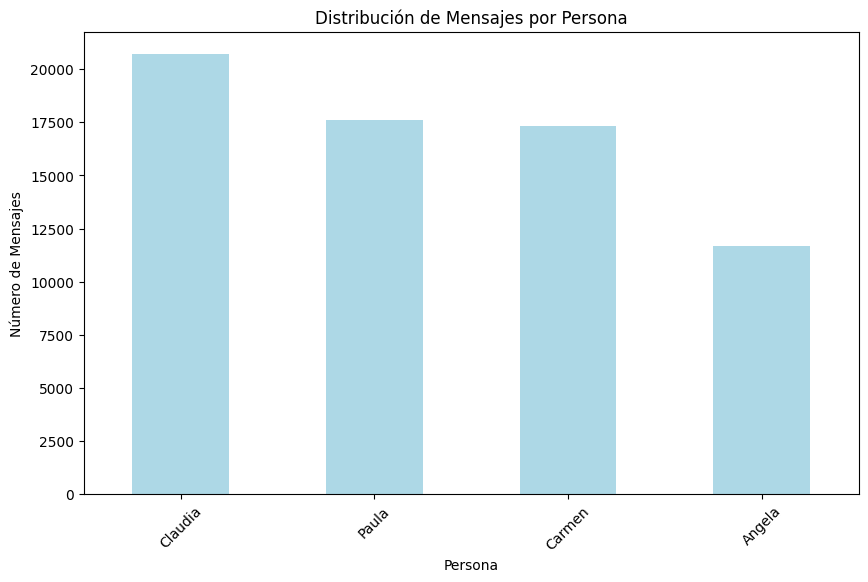


Número de Mensajes por Persona:
person
Claudia    20703
Paula      17624
Carmen     17348
Angela     11659
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# Contar cuántos mensajes ha enviado cada persona
persona_message_count = df['person'].value_counts()

# Graficar la distribución de mensajes por persona
plt.figure(figsize=(10, 6))
persona_message_count.plot(kind='bar', color='lightblue')
plt.title('Distribución de Mensajes por Persona')
plt.xlabel('Persona')
plt.ylabel('Número de Mensajes')
plt.xticks(rotation=45)
plt.show()

# Mostrar el número de mensajes por persona de manera tabular
print("\nNúmero de Mensajes por Persona:")
print(persona_message_count)

Esto muestra el balanceo de "clases" es decir la cantidad de mensajes que tenemos por cada clase (persona), que es aproximadamente balanceada. Se puede destacar que Claudia es la que envía más cantidad de mensajes.


Longitud Promedio de los Mensajes por Persona (en palabras):
person
Angela     5.481431
Carmen     4.746541
Claudia    3.683186
Paula      4.704267
Name: message_length_words, dtype: float64


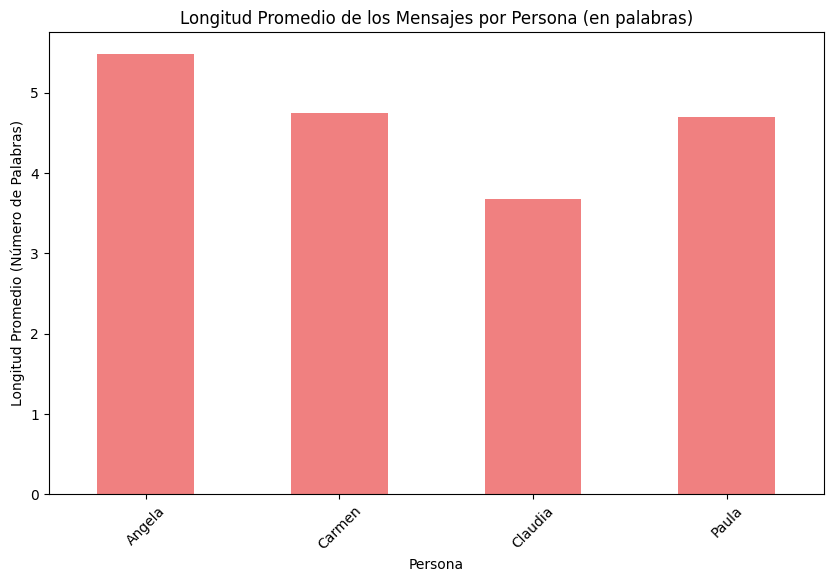

In [ ]:
# Calcular la longitud de cada mensaje en palabras
df['message_length_words'] = df['message'].apply(lambda x: len(x.split()))

# Agrupar por persona y calcular la longitud promedio en palabras
avg_message_length_by_person_words = df.groupby('person')['message_length_words'].mean()

# Mostrar los resultados
print("\nLongitud Promedio de los Mensajes por Persona (en palabras):")
print(avg_message_length_by_person_words)

# Graficar la longitud promedio de los mensajes por persona en palabras
avg_message_length_by_person_words.plot(kind='bar', color='lightcoral', figsize=(10, 6))
plt.title('Longitud Promedio de los Mensajes por Persona (en palabras)')
plt.xlabel('Persona')
plt.ylabel('Longitud Promedio (Número de Palabras)')
plt.xticks(rotation=45)
plt.show()

Podemos observar, que aunque Claudia era la participante que enviaba mayor número de mensajes, estos suelen ser más cortos que los del resto de participantes. Lo cual puede deducirse que es una participante que tiende a enviar muchos más mensajes pero más cortos. Al contrario de Ángela que envía muchos menos mensajes pero estos son más extensos.


Longitud Promedio de los Mensajes por Persona (en caracteres):
person
Angela     26.599451
Carmen     22.859638
Claudia    17.169975
Paula      23.623638
Name: message_length_chars, dtype: float64


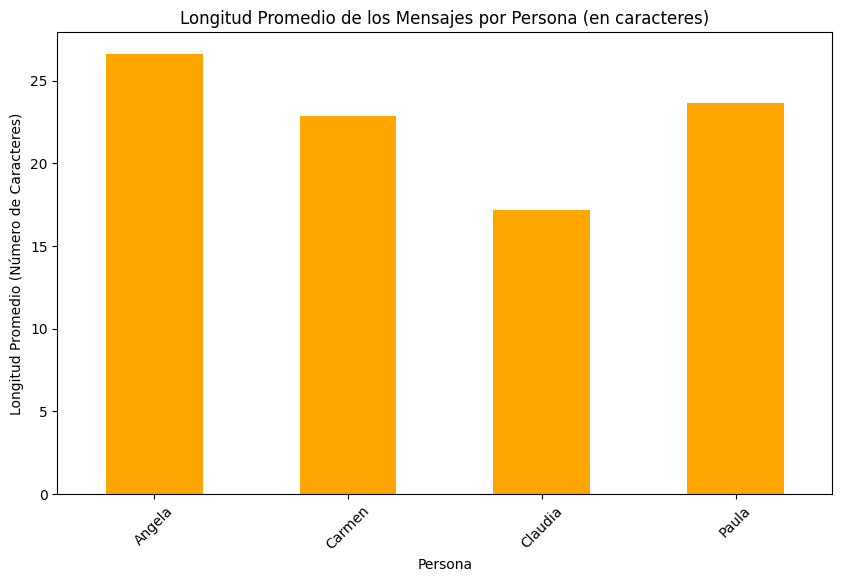

In [ ]:
# Calcular la longitud de cada mensaje en caracteres
df['message_length_chars'] = df['message'].apply(lambda x: len(x))

# Agrupar por persona y calcular la longitud promedio en caracteres
avg_message_length_by_person_chars = df.groupby('person')['message_length_chars'].mean()

# Mostrar los resultados
print("\nLongitud Promedio de los Mensajes por Persona (en caracteres):")
print(avg_message_length_by_person_chars)

# Graficar la longitud promedio de los mensajes por persona en caracteres
avg_message_length_by_person_chars.plot(kind='bar', color='orange', figsize=(10, 6))
plt.title('Longitud Promedio de los Mensajes por Persona (en caracteres)')
plt.xlabel('Persona')
plt.ylabel('Longitud Promedio (Número de Caracteres)')
plt.xticks(rotation=45)
plt.show()

Se pueden observar prácticamente los mismos resultados que en la figura del promedio de palabras por mensaje.


Las 10 Palabras Más Comunes en los Mensajes:
q: 10727
a: 7516
no: 6508
de: 6106
me: 5188
y: 5020
la: 4629
el: 4204
si: 3829
lo: 3623


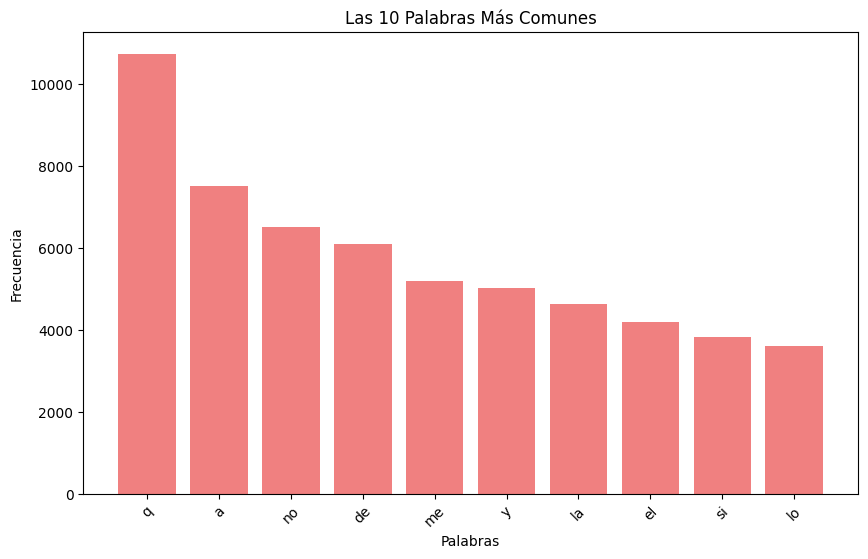

In [ ]:
from collections import Counter

# Contar las palabras en todos los mensajes
all_words = ' '.join(df['message']).split()
word_counts = Counter(all_words)

# Calcular las 10 palabras más comunes
common_words = word_counts.most_common(10)

# Mostrar las palabras más comunes de manera tabular
print("\nLas 10 Palabras Más Comunes en los Mensajes:")
for word, count in common_words:
    print(f"{word}: {count}")

# Graficar las 10 palabras más comunes
words, counts = zip(*common_words)
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='lightcoral')
plt.title('Las 10 Palabras Más Comunes')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

Como es natural, las preposiciones y artículos son las palabras más usadas. Posteriormente utilizaremos otras técnicas más robustas para encontrar cuáles son los temas más hablados sin tener en cuenta este tipo de palabras comunes.

In [ ]:
# Convertir la columna 'data_timestamp' a formato datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Verificar las fechas únicas
print(df['timestamp'].dt.year.unique())

/tmp/ipykernel_5055/3259280416.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')


[2022 2023 2024 2025 2026]


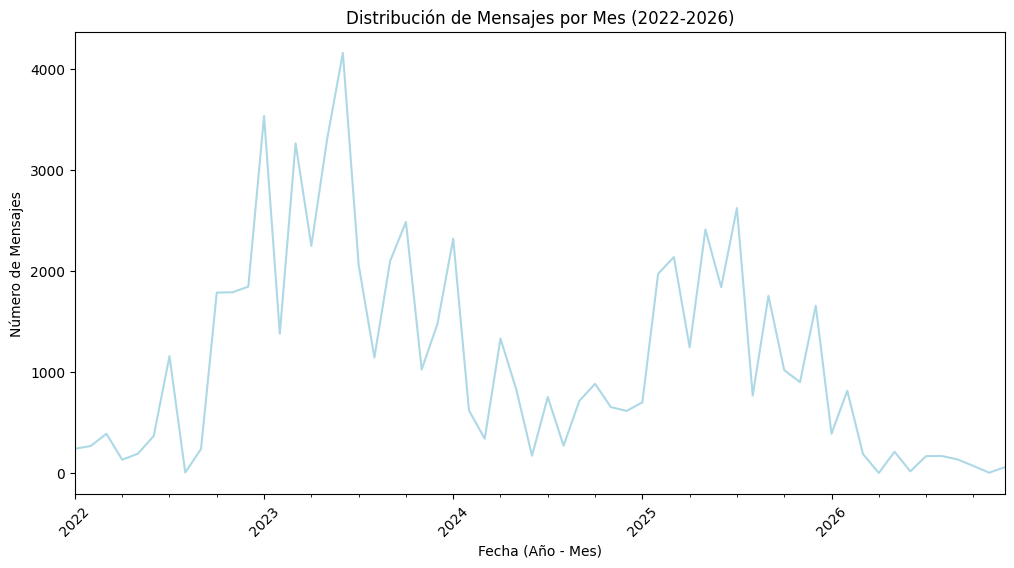

In [ ]:
# Agrupar por mes y año, y contar el número de mensajes
messages_by_month = df.groupby(df['timestamp'].dt.to_period('M')).size()

# Graficar la distribución de los mensajes por mes
messages_by_month.plot(kind='line', color='lightblue', figsize=(12, 6))
plt.title('Distribución de Mensajes por Mes (2022-2026)')
plt.xlabel('Fecha (Año - Mes)')
plt.ylabel('Número de Mensajes')
plt.xticks(rotation=45)
plt.show()

El año que más mensajes se escribieron fue a lo largo de 2023, teniendo otro pico también a mitad de 2025.

In [ ]:
# Guardar el DataFrame limpio en un archivo CSV
df.to_csv('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/data/dataframe_limpio.csv', index=False)